# Aging Interpolation (Leave-One-Aging-Out)

> **Authors:** Davide Corso, Marco Soldani  
> **Context:** Analysis of Galvanostatic Electrochemical Impedance Spectroscopy (GEIS) data on Lithium-Ion batteries (LiCoO₂).
>
**Expected Result:** Exclude an **entire Aging Level** (all 8 Nyquist plots across different temperatures × 5 SOC) and predict it using the other 4 Aging levels. By default, we exclude **Aging 2**, i.e. the central one: training is performed on Aging 0, 1, 3, and 4 → prediction is made on the 40 missing Nyquist diagrams.

This simulates a real-world scenario where we interpolate the battery behavior at an **unseen aging level that has never been measured**.

---

### Difference with the other previos LOO notebook (1: LOO)

| | Leave-One-Out (NB1) | Leave-One-Aging-Out (NB3) |
|---|---|---|
| **Excluded data** | 1 Aging × Temperature combination (~245 samples) | 1 full Aging level (~1960 samples, 40 Nyquist plots) |
| **Training** | 39 combinations | 32 combinations (4 Aging × 8 Temperature) |
| **Challenge** | Interpolate one missing plot among known neighbors | Interpolate an entire unseen aging level |
| **Available information** | Same Aging at other temperatures + same temperature at other aging levels | Only other aging levels, **no data from the excluded Aging** |

This is a **significantly more difficult task**: the model has no direct information about the excluded aging level and must truly *interpolate across aging states*.

# 1. Setup

In [1]:
import sys
assert sys.version_info >= (3, 5), "Python 3.5+ is required"

# --- STANDARD LIBRARIES ---
import warnings
import time

# --- SCIENTIFIC LIBRARIES ---
import numpy as np
import pandas as pd

# --- VISUALIZATION ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- MACHINE LEARNING ---
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    BaggingRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

# --- CONFIGURATION ---
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rc("axes", labelsize=13)
mpl.rc("xtick", labelsize=11)
mpl.rc("ytick", labelsize=11)
mpl.rc("legend", fontsize=10)
mpl.rc("figure", dpi=120)

# --- CONSTANTS ---
RANDOM_SEED = 42

TEMP_COLORS = {
    20.0: "#1b9e77",
    22.5: "#d95f02",
    25.0: "#7570b3",
    27.5: "#e7298a",
    30.0: "#66a61e",
    35.0: "#e6ab02",
    40.0: "#a6761d",
    47.5: "#1f3a93",
}

AGING_LABELS = {
    0: "Aging 0 (Fresh)",
    1: "Aging 1",
    2: "Aging 2",
    3: "Aging 3",
    4: "Aging 4 (Aged)",
}

SOC_MARKERS = {
    0: "o",
    1: "s",
    2: "^",
    3: "D",
    4: "v",
}

AGINGS = [0, 1, 2, 3, 4]

# --- ENVIRONMENT INFO ---
def print_environment_info():
    import sklearn

    print("Setup completed")
    print(
        f"Python {sys.version_info.major}.{sys.version_info.minor} | "
        f"NumPy {np.__version__} | "
        f"Pandas {pd.__version__} | "
        f"Scikit-learn {sklearn.__version__}"
    )


print_environment_info()

Setup completed
Python 3.12 | NumPy 2.0.1 | Pandas 2.3.3 | Scikit-learn 1.7.1


# 2. Data Loading

Loading the cleaned dataset from the CSV file generated from the original `.mat` data.

In [2]:
# --- LOAD CSV ---

from pathlib import Path

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    import os
    current_dir = Path(os.getcwd())

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

file_path = project_root / "data" / "processed" / "batteries_cleaned_dataset.csv"
print(f"Looking for file at: {file_path}")

if not file_path.exists():
    raise FileNotFoundError(f"CSV file not found at: {file_path}")

df = pd.read_csv(file_path)

# Sort for better DataFrame readability
df = df.sort_values(
    ["Aging", "Temperature", "SOC", "Frequency"]
).reset_index(drop=True)

TEMPS_SORTED = sorted(df["Temperature"].unique())
SOCS_SORTED = sorted(df["SOC"].unique())

# --- DATASET SUMMARY ---
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Aging levels: {sorted(df['Aging'].unique())}")
print(f"Temperatures: {TEMPS_SORTED} °C")
print(f"SOCs: {SOCS_SORTED}")
print(
    f"Frequency range: {df['Frequency'].min():.2f} – {df['Frequency'].max():.0f} Hz"
)
print(
    "Combinations (Aging × Temperature × SOC): "
    f"{df.groupby(['Aging','Temperature','SOC']).ngroups}"
)

df.head()

Looking for file at: /Users/davidecorso/Desktop/SUPSI/Progetto_Semestre/git/ml_LiBs_project/data/processed/batteries_cleaned_dataset.csv
Dataset loaded: 9,805 rows × 6 columns
Aging levels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Temperatures: [np.float64(20.0), np.float64(22.5), np.float64(25.0), np.float64(27.5), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(47.5)] °C
SOCs: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Frequency range: 0.10 – 10002 Hz
Combinations (Aging × Temperature × SOC): 200


,Aging,Temperature,SOC,Frequency,Z_real,neg_Z_imag
0,0,20.0,0,0.126502,6.089266,0.467721
1,0,20.0,0,0.160118,6.057238,0.388003
2,0,20.0,0,0.202344,6.022578,0.322534
3,0,20.0,0,0.255913,5.991356,0.273686
4,0,20.0,0,0.323687,5.969386,0.238370


# 3. EDA and Aging 2

Before proceeding, we visualize how impedance changes across different Aging levels. This allows us to assess whether the interpolation task is actually feasible or if the gaps between aging states are too large.

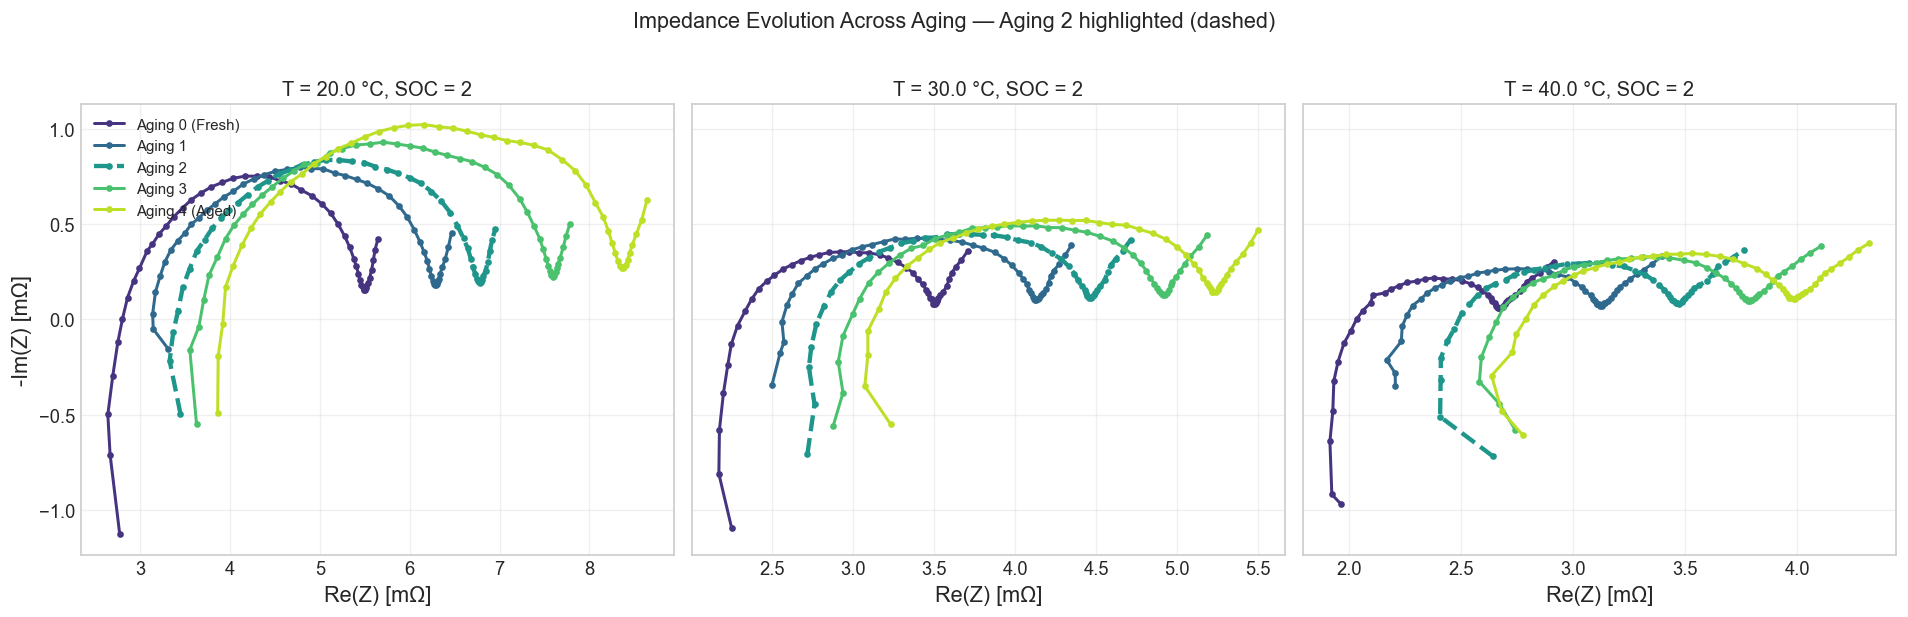

In [3]:
# --- NYQUIST EVOLUTION ACROSS AGING (FIXED SOC AND TEMPERATURES) ---

# We fix SOC=2 (medium) and visualize all aging levels for 3 representative temperatures

TEMPS_EDA = [20.0, 30.0, 40.0]
SOC_EDA = 2
AGING_TO_EXCLUDE = 2

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

aging_cmap = plt.cm.viridis(np.linspace(0.15, 0.9, 5))

for ax, temp in zip(axes, TEMPS_EDA):

    for ep in AGINGS:

        subset = df[
            (df["Aging"] == ep)
            & (df["Temperature"] == temp)
            & (df["SOC"] == SOC_EDA)
        ]

        subset = subset.sort_values("Frequency", ascending=False)

        style = "--" if ep == AGING_TO_EXCLUDE else "-"
        lw = 2.6 if ep == AGING_TO_EXCLUDE else 1.8

        ax.plot(
            subset["Z_real"],
            subset["neg_Z_imag"],
            color=aging_cmap[ep],
            lw=lw,
            ls=style,
            marker="o",
            markersize=3,
            label=AGING_LABELS[ep],
        )

    ax.set_title(f"T = {temp} °C, SOC = {SOC_EDA}", fontsize=12)
    ax.set_xlabel("Re(Z) [mΩ]")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("-Im(Z) [mΩ]")

axes[0].legend(
    loc="upper left",
    fontsize=9,
    framealpha=0.9,
)

fig.suptitle(
    f"Impedance Evolution Across Aging — Aging {AGING_TO_EXCLUDE} highlighted (dashed)",
    fontsize=13,
    y=1.02,
)

plt.tight_layout()
plt.show()

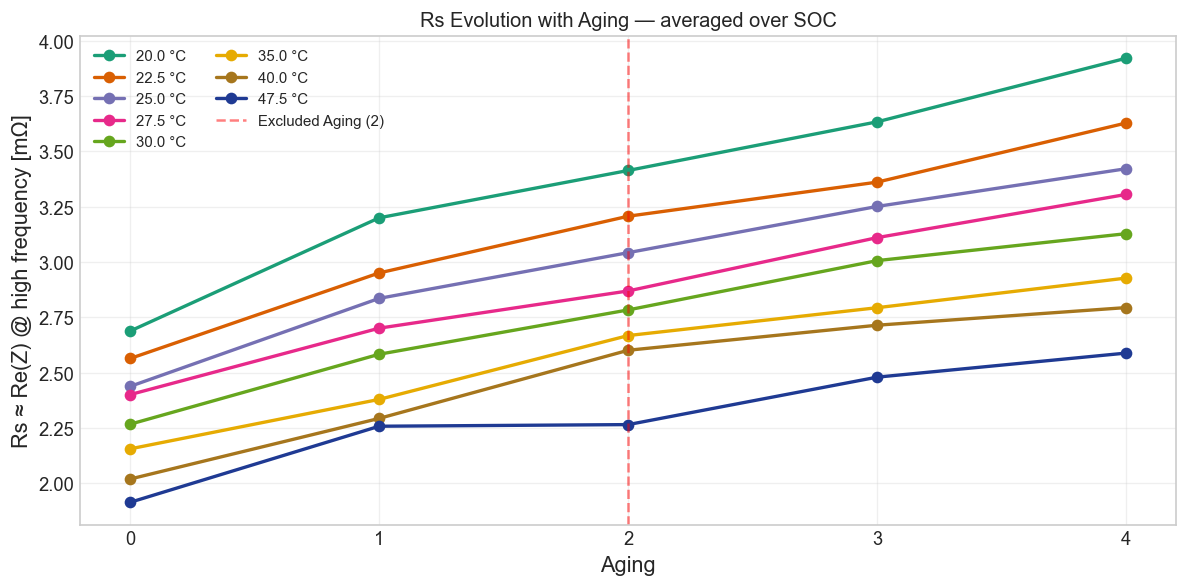

The monotonic trend of Rs with aging suggests that interpolation is physically meaningful.


In [4]:
# --- Rs DRIFT (HIGH-FREQUENCY RESISTANCE) WITH AGING ---

# We extract the highest-frequency point as a proxy for Rs

rs_proxy = (
    df.sort_values("Frequency", ascending=False)
      .groupby(["Aging", "Temperature", "SOC"])
      .first()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

for temp in TEMPS_SORTED:
    subset = rs_proxy[rs_proxy["Temperature"] == temp]
    series = subset.groupby("Aging")["Z_real"].mean()

    ax.plot(
        series.index,
        series.values,
        marker="o",
        lw=2,
        color=TEMP_COLORS[temp],
        label=f"{temp} °C",
    )

ax.axvline(
    AGING_TO_EXCLUDE,
    color="red",
    ls="--",
    alpha=0.5,
    label=f"Excluded Aging ({AGING_TO_EXCLUDE})",
)

ax.set_xlabel("Aging")
ax.set_ylabel("Rs ≈ Re(Z) @ high frequency [mΩ]")
ax.set_title("Rs Evolution with Aging — averaged over SOC")

ax.set_xticks(AGINGS)
ax.legend(ncol=2, fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    "The monotonic trend of Rs with aging suggests that interpolation is physically meaningful."
)

# 4. Feature Engineering

The same 9 features used in NB1, with physical justification:
>
> - **Base features**: `Aging`, `Temperature`, `SOC`, `Frequency`

> - **Log-frequency**: `log_Freq = log10(Freq)` — frequencies span 5 decades, and a logarithmic scale is physically meaningful for impedance behavior

> - **Arrhenius term**: `inv_Temp = 1/(T + 273.15)` — captures the exponential dependence of resistance on temperature

> - **Interaction terms**: `Aging×Temp`, `SOC×Temp`, `SOC×Aging` — effects are not independent; aging modulates both temperature and SOC response

In [5]:
def build_features(data: pd.DataFrame) -> pd.DataFrame:
    """Build the 9-feature set from the raw DataFrame."""
    return pd.DataFrame({
        "Aging":        data["Aging"].values,
        "Temperature":  data["Temperature"].values,
        "SOC":          data["SOC"].values,
        "Frequency":    data["Frequency"].values,
        "log_Freq":     np.log10(data["Frequency"].values),
        "inv_Temp":     1.0 / (data["Temperature"].values + 273.15),
        "Aging_x_Temp": data["Aging"].values * data["Temperature"].values,
        "SOC_x_Temp":   data["SOC"].values * data["Temperature"].values,
        "SOC_x_Aging":  data["SOC"].values * data["Aging"].values,
    })


# --- SPLIT: ENTIRE AGING LEVEL IS HELD OUT FOR TESTING ---

train_mask = df["Aging"] != AGING_TO_EXCLUDE
test_mask  = df["Aging"] == AGING_TO_EXCLUDE

X_train = build_features(df[train_mask])
X_test  = build_features(df[test_mask])

y_train = df[train_mask][["Z_real", "neg_Z_imag"]].values
y_test  = df[test_mask][["Z_real", "neg_Z_imag"]].values

# --- SCALING (fit only on training set) ---

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]:,} rows × {X_test.shape[1]} features")

print(
    f"-> Test set corresponds to entire Aging {AGING_TO_EXCLUDE}: "
    f"{df[test_mask].groupby(['Temperature','SOC']).ngroups} Nyquist diagrams to predict"
)

Training set: 7,845 rows × 9 features
Test set:     1,960 rows × 9 features
-> Test set corresponds to entire Aging 2: 40 Nyquist diagrams to predict


# 5. Benchmark - 5 models

We compare 5 models trained using **MultiOutputRegressor** since we predict both `Z_real` and `neg_Z_imag` simultaneously.

**Strategy**: first we run a benchmark using default hyperparameters, then we perform tuning only on the best-performing model.

In [6]:
# --- DEFINE MODELS ---

models = {
    "Ridge": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=200,
            random_state=RANDOM_SEED
        )
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5,
        weights="distance",
        n_jobs=-1
    ),

    "Bagging Ridge": BaggingRegressor(
        estimator=Ridge(alpha=1.0),
        n_estimators=50,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),
}

# --- TRAINING AND EVALUATION ---

results = []
predictions = {}

print(f"{'Model':<20}{'R²':>10}{'MSE':>12}{'MAE':>12}{'Time [s]':>12}")
print("─" * 66)

for name, model in models.items():

    t0 = time.time()

    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    elapsed = time.time() - t0

    # --- METRICS (multi-output aggregated) ---
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R²": r2,
        "MSE": mse,
        "MAE": mae,
        "Time [s]": elapsed
    })

    predictions[name] = y_pred

    print(f"{name:<20}{r2:>10.4f}{mse:>12.4f}{mae:>12.4f}{elapsed:>12.2f}")

# --- RESULTS TABLE ---

results_df = (
    pd.DataFrame(results)
    .sort_values("R²", ascending=False)
    .reset_index(drop=True)
)

best_name = results_df.iloc[0]["Model"]

print(f"\nBest model: {best_name} (R² = {results_df.iloc[0]['R²']:.4f})")

Model                       R²         MSE         MAE    Time [s]
──────────────────────────────────────────────────────────────────
Ridge                   0.7293      0.1919      0.2930        0.00


Random Forest           0.9739      0.0303      0.0986        0.29


Gradient Boosting       0.9653      0.0278      0.1092        1.26
KNN                     0.9860      0.0079      0.0633        0.02


Bagging Ridge           0.7292      0.1919      0.2934        1.36

Best model: KNN (R² = 0.9860)


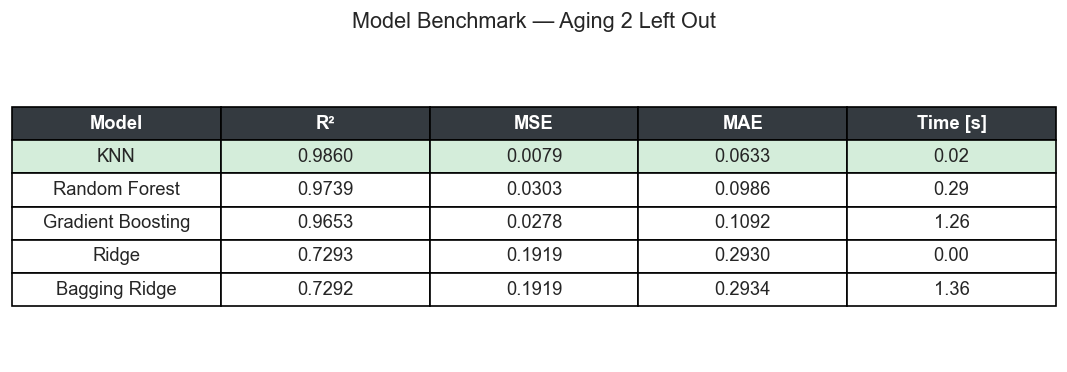

In [7]:
# --- TABLE VISUALIZATION ---

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")

# copy and format results
table_data = results_df.copy()

table_data["R²"] = table_data["R²"].map("{:.4f}".format)
table_data["MSE"] = table_data["MSE"].map("{:.4f}".format)
table_data["MAE"] = table_data["MAE"].map("{:.4f}".format)
table_data["Time [s]"] = table_data["Time [s]"].map("{:.2f}".format)

# create table
tbl = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    cellLoc="center",
    loc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)

# --- header styling ---
for j in range(len(table_data.columns)):
    tbl[(0, j)].set_facecolor("#343a40")
    tbl[(0, j)].set_text_props(color="white", weight="bold")

# --- highlight best model ---
best_row = results_df.index[0] + 1  # +1 because header row is 0

for j in range(len(table_data.columns)):
    tbl[(best_row, j)].set_facecolor("#d4edda")

plt.title(
    f"Model Benchmark — Aging {AGING_TO_EXCLUDE} Left Out",
    pad=15,
    fontsize=13
)

plt.tight_layout()
plt.show()

# 6. Tuning of the Best Model with GridSearchCV

We refine the best-performing model from the benchmark using GridSearchCV. The hyperparameter grid is selected dynamically based on the automatically chosen model.

In [8]:
# --- HYPERPARAMETER GRIDS PER MODEL ---

param_grids = {
    'Ridge': {
        'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
    },
    'Random Forest': {
        'n_estimators': [200, 400],
        'max_depth': [None, 15, 25],
        'min_samples_split': [2, 5],
    },
    'Gradient Boosting': {
        'estimator__n_estimators': [200, 400],
        'estimator__learning_rate': [0.05, 0.1],
        'estimator__max_depth': [3, 5],
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 10, 15],
        'weights': ['uniform', 'distance'],
        'p': [1, 2],
    },
    'Bagging Ridge': {
        'n_estimators': [50, 100],
        'estimator__alpha': [0.1, 1.0, 10.0],
    },
}

base_models = {
    'Ridge': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
    'Gradient Boosting': MultiOutputRegressor(
        GradientBoostingRegressor(random_state=RANDOM_SEED)
    ),
    'KNN': KNeighborsRegressor(n_jobs=-1),
    'Bagging Ridge': BaggingRegressor(
        estimator=Ridge(), random_state=RANDOM_SEED, n_jobs=-1
    ),
}

# --- GROUP-AWARE CV: LeaveOneGroupOut on Aging ---
# This mirrors the test task (holding out an entire Aging level),
# so CV scores reflect extrapolation across Aging, not within-Aging interpolation.
logo = LeaveOneGroupOut()
groups_train = df[train_mask]["Aging"].values

print(f"GridSearchCV on '{best_name}' — CV folds: {logo.get_n_splits(groups=groups_train)}")

t0 = time.time()

grid = GridSearchCV(
    base_models[best_name],
    param_grids[best_name],
    cv=logo.split(X_train_s, y_train, groups=groups_train),
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train_s, y_train)

elapsed = time.time() - t0

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_s)

r2_tuned = r2_score(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print(f"Completed in {elapsed:.1f} s")
print(f"Best parameters: {grid.best_params_}")

print(f"\nR² (default) = {results_df.iloc[0]['R²']:.4f}")
print(f"R² (tuned)   = {r2_tuned:.4f}\n")

print(f"MSE (default) = {results_df.iloc[0]['MSE']:.4f}")
print(f"MSE (tuned)  = {mse_tuned:.4f}\n")

print(f"MAE (default) = {results_df.iloc[0]['MAE']:.4f}")
print(f"MAE (tuned)  = {mae_tuned:.4f}")

GridSearchCV on 'KNN' — CV folds: 4


Completed in 0.2 s
Best parameters: {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}

R² (default) = 0.9860
R² (tuned)   = 0.9835

MSE (default) = 0.0079
MSE (tuned)  = 0.0139

MAE (default) = 0.0633
MAE (tuned)  = 0.0844


# 7. Temperature-wise Analysis

We compute R² and MAE separately for each temperature in the left-out Aging. This allows us to evaluate whether the model interpolates better at certain temperatures compared to others.

In [9]:
df_test = df[test_mask].reset_index(drop=True).copy()

df_test["Z_real_pred"] = y_pred_tuned[:, 0]
df_test["neg_neg_Z_imag_pred"] = y_pred_tuned[:, 1]

per_temp = []

for temp in TEMPS_SORTED:
    sub = df_test[df_test["Temperature"] == temp]

    r2_t = r2_score(
        sub[["Z_real", "neg_Z_imag"]].values,
        sub[["Z_real_pred", "neg_neg_Z_imag_pred"]].values
    )

    mae_t = mean_absolute_error(
        sub[["Z_real", "neg_Z_imag"]].values,
        sub[["Z_real_pred", "neg_neg_Z_imag_pred"]].values
    )

    per_temp.append({
        "Temperature [°C]": temp,
        "R²": r2_t,
        "MAE [mΩ]": mae_t,
        "N points": len(sub)
    })

per_temp_df = pd.DataFrame(per_temp)

print(
    per_temp_df.to_string(
        index=False,
        formatters={
            "R²": "{:.4f}".format,
            "MAE [mΩ]": "{:.4f}".format
        }
    )
)

 Temperature [°C]     R² MAE [mΩ]  N points
             20.0 0.9750   0.1419       245
             22.5 0.9847   0.0927       245
             25.0 0.9786   0.0957       245
             27.5 0.9831   0.0806       245
             30.0 0.9759   0.0834       245
             35.0 0.9739   0.0646       245
             40.0 0.9704   0.0580       245
             47.5 0.9480   0.0584       245


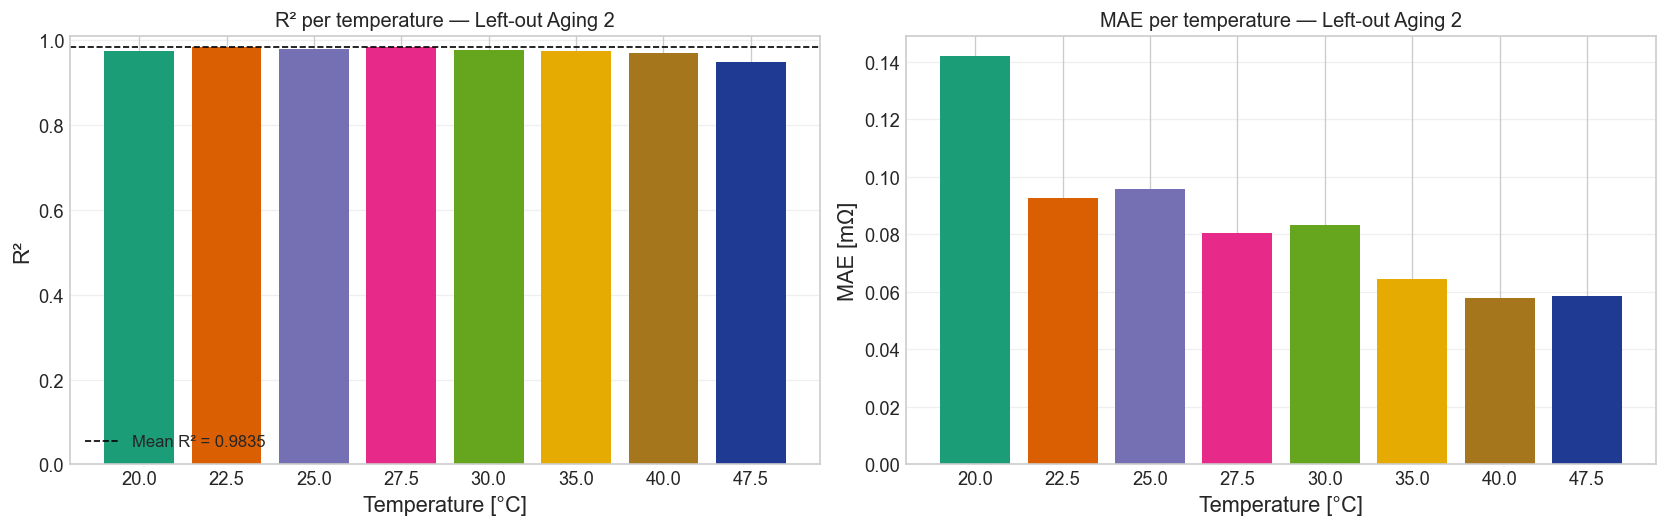

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

colors = [TEMP_COLORS[t] for t in per_temp_df["Temperature [°C]"]]

# --- R² per temperature ---
axes[0].bar(
    per_temp_df["Temperature [°C]"].astype(str),
    per_temp_df["R²"],
    color=colors
)

axes[0].axhline(
    r2_tuned,
    color="black",
    ls="--",
    lw=1,
    label=f"Mean R² = {r2_tuned:.4f}"
)

axes[0].set_xlabel("Temperature [°C]")
axes[0].set_ylabel("R²")
axes[0].set_title(f"R² per temperature — Left-out Aging {AGING_TO_EXCLUDE}")
axes[0].set_ylim(min(0, per_temp_df["R²"].min() - 0.05), 1.01)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# --- MAE per temperature ---
axes[1].bar(
    per_temp_df["Temperature [°C]"].astype(str),
    per_temp_df["MAE [mΩ]"],
    color=colors
)

axes[1].set_xlabel("Temperature [°C]")
axes[1].set_ylabel("MAE [mΩ]")
axes[1].set_title(f"MAE per temperature — Left-out Aging {AGING_TO_EXCLUDE}")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# 8. Visualization — All 40 Predicted vs True Nyquist Plots

We display **each individual Nyquist plot** of the left-out Aging (8 temperatures × 5 SOC = 40 plots).

For each subplot:
- The **true curve** is shown as a solid colored line  
- The **predicted curve** is shown as a dashed black line  
- The **R² score** is reported on top, computed for that specific Nyquist plot  

This provides a detailed view of how well the model reconstructs the impedance spectrum across all operating conditions.

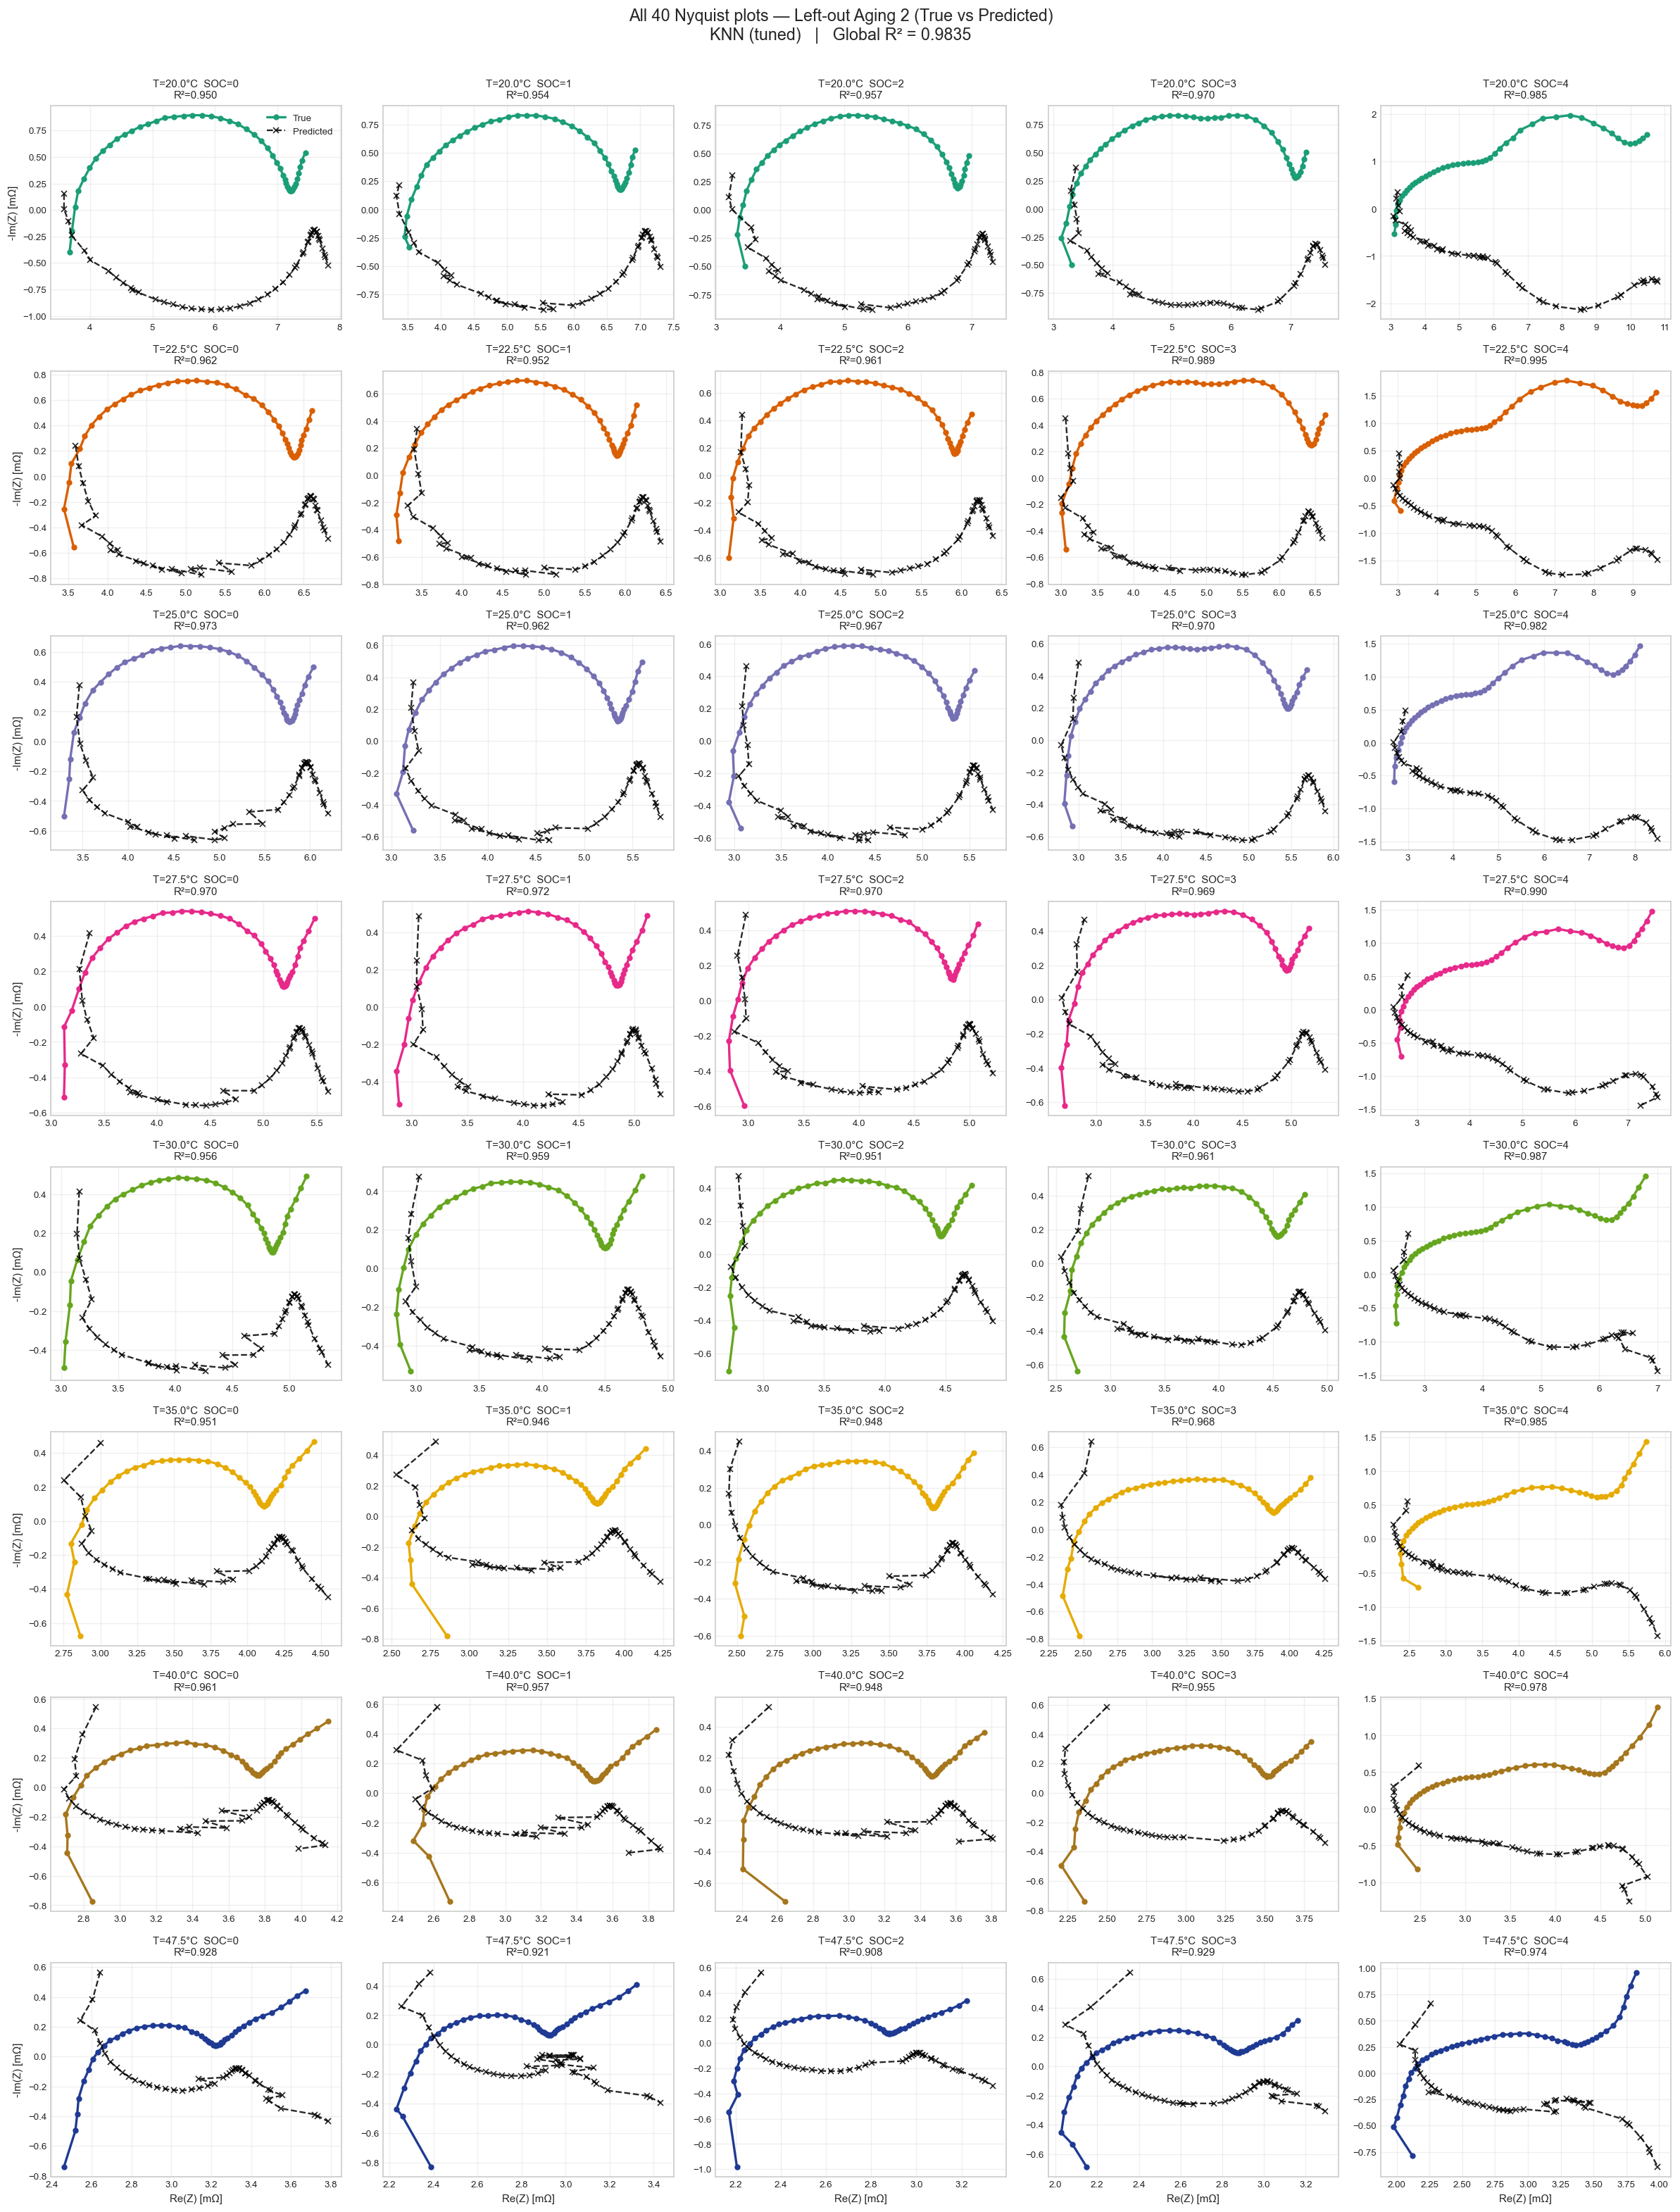

In [11]:
# --- 8x5 GRID: all 40 Nyquist plots (8 Temperatures × 5 SOC) ---
# Each subplot shows the true Nyquist (solid line) vs predicted (dashed)

n_temps = len(TEMPS_SORTED)
n_socs  = len(SOCS_SORTED)

fig, axes = plt.subplots(n_temps, n_socs, figsize=(20, 26), sharex=False, sharey=False)

for i, temp in enumerate(TEMPS_SORTED):
    for j, soc in enumerate(SOCS_SORTED):
        ax = axes[i, j]

        sub = df_test[
            (df_test["Temperature"] == temp) &
            (df_test["SOC"] == soc)
        ].sort_values("Frequency", ascending=False)

        if len(sub) == 0:
            ax.set_visible(False)
            continue

        color = TEMP_COLORS[temp]

        # --- True curve ---
        ax.plot(
            sub["Z_real"], sub["neg_Z_imag"],
            color=color, lw=2,
            marker="o", markersize=4,
            label="True", zorder=2
        )

        # --- Predicted curve ---
        ax.plot(
            sub["Z_real_pred"], -sub["neg_neg_Z_imag_pred"],
            color="black", lw=1.4, ls="--",
            marker="x", markersize=5,
            alpha=0.85,
            label="Predicted", zorder=3
        )

        # --- Local R² ---
        r2_local = r2_score(
            sub[["Z_real", "neg_Z_imag"]].values,
            sub[["Z_real_pred", "neg_neg_Z_imag_pred"]].values
        )

        ax.set_title(f"T={temp}°C  SOC={soc}\nR²={r2_local:.3f}", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.3)

        if i == n_temps - 1:
            ax.set_xlabel("Re(Z) [mΩ]", fontsize=9)
        if j == 0:
            ax.set_ylabel("-Im(Z) [mΩ]", fontsize=9)

        if i == 0 and j == 0:
            ax.legend(loc="best", fontsize=8, framealpha=0.9)

fig.suptitle(
    f"All 40 Nyquist plots — Left-out Aging {AGING_TO_EXCLUDE} (True vs Predicted)\n"
    f"{best_name} (tuned)   |   Global R² = {r2_tuned:.4f}",
    fontsize=14,
    y=1.005
)

plt.tight_layout()
plt.show()

# 9. Error Analysis — Distribution and Frequency Dependence

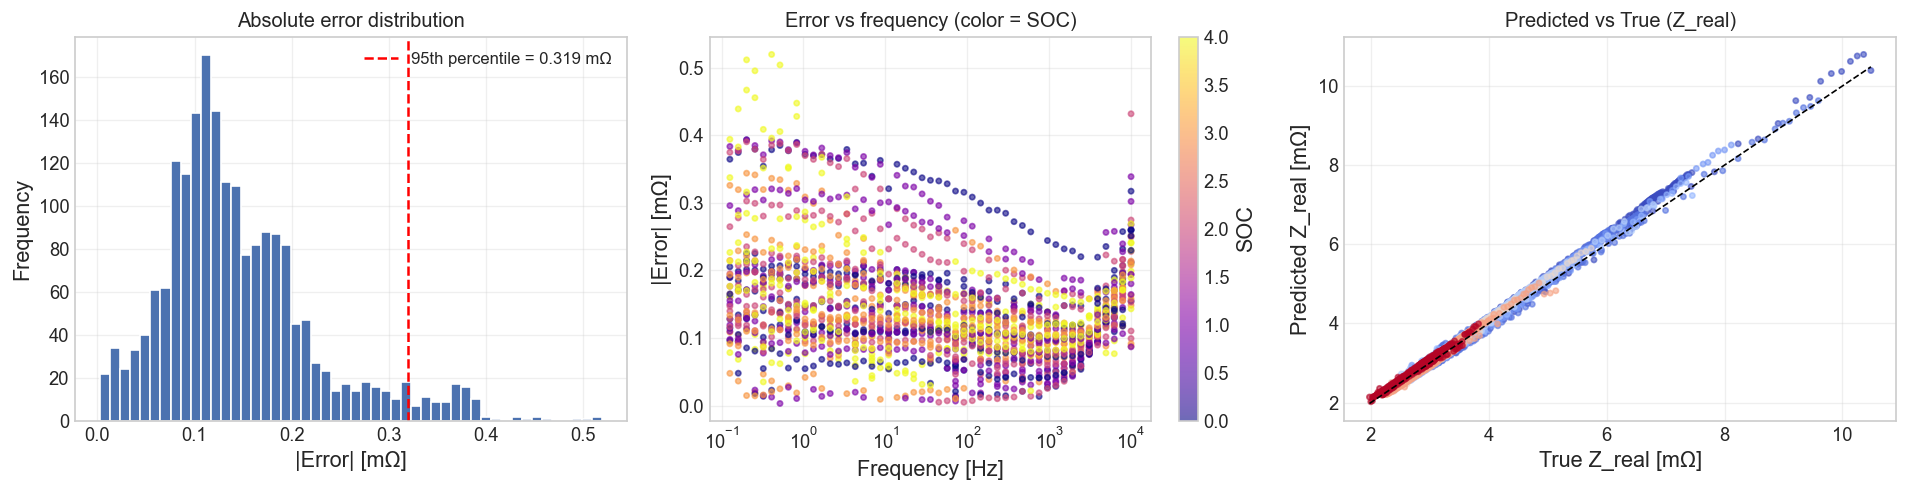

In [12]:
df_test["err_real"] = df_test["Z_real_pred"] - df_test["Z_real"]
df_test["err_imag"] = df_test["neg_neg_Z_imag_pred"] - df_test["neg_Z_imag"]
df_test["err_abs"]  = np.sqrt(df_test["err_real"]**2 + df_test["err_imag"]**2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# --- Error distribution ---
axes[0].hist(
    df_test["err_abs"],
    bins=50,
    color="#4c72b0",
    edgecolor="white"
)

p95 = np.percentile(df_test["err_abs"], 95)

axes[0].axvline(
    p95,
    color="red",
    ls="--",
    lw=1.5,
    label=f"95th percentile = {p95:.3f} mΩ"
)

axes[0].set_xlabel("|Error| [mΩ]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Absolute error distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Error vs frequency ---
sc = axes[1].scatter(
    df_test["Frequency"],
    df_test["err_abs"],
    c=df_test["SOC"],
    cmap="plasma",
    s=10,
    alpha=0.6
)

axes[1].set_xscale("log")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("|Error| [mΩ]")
axes[1].set_title("Error vs frequency (color = SOC)")
axes[1].grid(True, alpha=0.3)

plt.colorbar(sc, ax=axes[1], label="SOC")

# --- Predicted vs true (Z_real) ---
axes[2].scatter(
    df_test["Z_real"],
    df_test["Z_real_pred"],
    c=df_test["Temperature"],
    cmap="coolwarm",
    s=10,
    alpha=0.6
)

lims = [df_test["Z_real"].min(), df_test["Z_real"].max()]
axes[2].plot(lims, lims, "k--", lw=1)

axes[2].set_xlabel("True Z_real [mΩ]")
axes[2].set_ylabel("Predicted Z_real [mΩ]")
axes[2].set_title("Predicted vs True (Z_real)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Conclusions

## Pipeline — Aging Interpolation (Leave-One-Aging-Out)

1. **Setup** — import of libraries.
2. **Data loading** — reading `batteries_cleaned_dataset.csv`.
3. **EDA and Aging 2** — Nyquist evolution across all 5 Aging levels at fixed SOC and 3 temperatures, plus Rs proxy drift vs Aging to validate the smoothness of the trend.
4. **Feature engineering** — 9 physically motivated features (same as NB1): 4 base + `log_Freq` + `inv_Temp` + 3 interaction terms.
5. **Benchmark of 5 models** — Ridge, Random Forest, Gradient Boosting, KNN, Bagging Ridge; `MultiOutputRegressor` wrapped **only around Gradient Boosting**, since the other four natively support multi-output. Evaluation via R², MSE, MAE, training time.
6. **Hyperparameter tuning (GridSearchCV)** — performed only on the best model from step 5, with a model-specific parameter grid. CV uses `LeaveOneGroupOut` on `Aging`, so every fold holds out a full aging level: the CV score measures extrapolation across aging, matching the held-out test task.
7. **Temperature-wise analysis** — R² and MAE per temperature, visualized as bar charts with the global R² as reference line.
8. **Full grid visualization** — 40 subplots of true vs predicted Nyquist curves, with per-plot R².
9. **Error analysis** — `|error|` distribution with 95th percentile, `|error|` vs frequency, predicted vs true `Z_real`.

> **Note on tree-based models.** Random Forest and Gradient Boosting cannot extrapolate beyond the range of aging values seen in training: with `Aging ∈ {0, 1, 3, 4}` held in, they can only predict values observed at training-time aging levels. KNN with distance weights is unaffected because it blends the nearest points in scaled feature space. This is a structural property of the models, not a tuning issue.

## Comparison with NB1, NB2

| Metric | Leave-One-Out (NB1) | Classification Ages (NB2) | Aging Interpolation (NB3) |
|---|---|---|---|
| Task | Regression | Classification | Regression |
| Target | Z_real, neg_Z_imag | Young vs Old | Z_real, neg_Z_imag |
| Data excluded | ~245 points (1/40) | 20% group-aware split (`StratifiedGroupKFold`) | ~1960 points — 40 Nyquist plots (1/5) |
| Models benchmarked | 5 | 6 | 5 |
| Difficulty | Medium | Low | **High** |